Descargando MSFT (liquido) y GME (iliquido)...


/tmp/ipykernel_437/2213032504.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval, progress=False)
/tmp/ipykernel_437/2213032504.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval, progress=False)


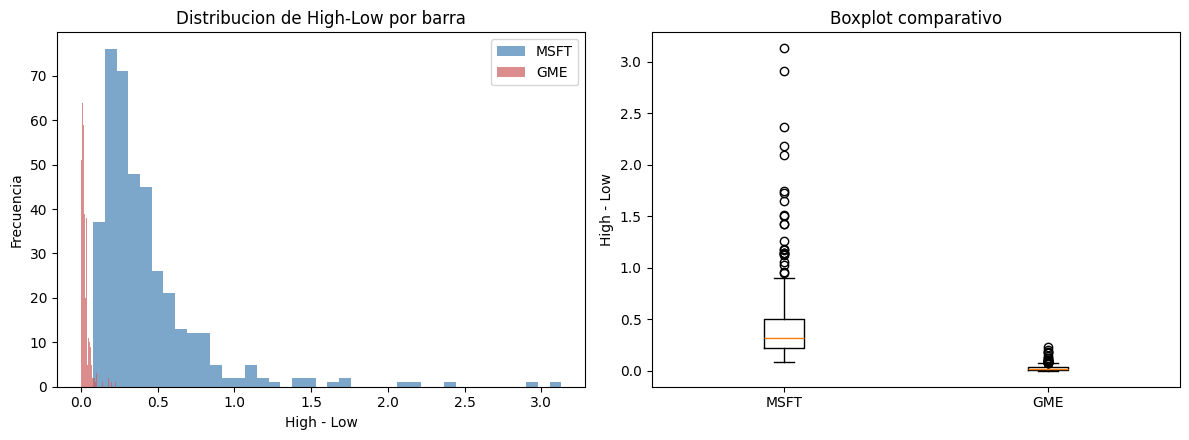


MSFT: media=0.42865  mediana=0.32001  std=0.36767
GME: media=0.02737  mediana=0.02000  std=0.02843

Calibracion GBM (MSFT): mu_anual=-0.8849  sigma_anual=0.1919

--- Verificacion identidad media/mediana (GBM) ---
Media simulada:    507.4089   |  Media teorica:    507.3154   | error rel: 0.0184%
Mediana simulada:  507.3356   |  Mediana teorica:  507.2784   | error rel: 0.0113%
(La media > mediana porque S_T es log-normal -- consecuencia directa de la desigualdad de Jensen sobre exp(.), no un error de simulacion.)


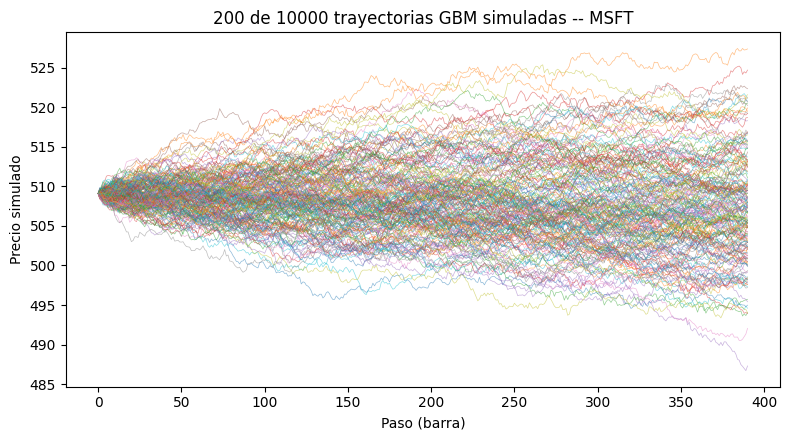


--- Deteccion numerica de violacion de supuestos BSM ---
Jarque-Bera stat=540.15, p-value=5.094e-118  (p < 0.05 rechaza normalidad de los retornos)
Exceso de curtosis=5.67  (>0 indica colas mas pesadas que la normal)
Coef. de variacion de la vol. movil (ventana=19 barras)=42.11%  (>0 indica que la volatilidad NO es constante)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats


ILLIQUID_TICKER = "GME"
LIQUID_TICKER = "MSFT" # Added definition for LIQUID_TICKER
INTERVAL = "1m"
PERIOD = "5d"

N_PATHS = 10_000
SEED = 42



def download_intraday(ticker: str, period: str = PERIOD, interval: str = INTERVAL) -> pd.DataFrame:
    """Descarga barras intradia y regresa solo el ultimo dia de trading completo."""
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    if df.empty:
        raise ValueError(f"No se recibieron datos para {ticker}. Revisa el ticker o el rango.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.index = pd.to_datetime(df.index)
    ultimo_dia = df.index.date.max()
    df_dia = df[df.index.date == ultimo_dia].copy()
    return df_dia



def tightness_proxy(df: pd.DataFrame) -> pd.Series:
    """High-Low por barra. No es un spread real (Yahoo no publica libro de ordenes),
    pero aproxima cuanto se movio el precio dentro del minuto."""
    return df["High"] - df["Low"]


def plot_tightness_comparison(hl_liquido: pd.Series, hl_iliquido: pd.Series,
                               nombre_liquido: str, nombre_iliquido: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].hist(hl_liquido, bins=40, alpha=0.7, color="steelblue", label=nombre_liquido)
    axes[0].hist(hl_iliquido, bins=40, alpha=0.7, color="indianred", label=nombre_iliquido)
    axes[0].set_title("Distribucion de High-Low por barra")
    axes[0].set_xlabel("High - Low")
    axes[0].set_ylabel("Frecuencia")
    axes[0].legend()

    axes[1].boxplot([hl_liquido.dropna(), hl_iliquido.dropna()],
                     tick_labels=[nombre_liquido, nombre_iliquido])
    axes[1].set_title("Boxplot comparativo")
    axes[1].set_ylabel("High - Low")

    fig.tight_layout()
    fig.savefig("tightness_comparison.png", dpi=150)
    plt.show()

    print(f"\n{nombre_liquido}: media={hl_liquido.mean():.5f}  mediana={hl_liquido.median():.5f}  "
          f"std={hl_liquido.std():.5f}")
    print(f"{nombre_iliquido}: media={hl_iliquido.mean():.5f}  mediana={hl_iliquido.median():.5f}  "
          f"std={hl_iliquido.std():.5f}")



def calibrar_gbm(precios: pd.Series, barras_por_anio: float):
    """Estima mu y sigma (anualizados) a partir de log-retornos realizados."""
    log_ret = np.log(precios / precios.shift(1)).dropna()
    mu = log_ret.mean() * barras_por_anio
    sigma = log_ret.std() * np.sqrt(barras_por_anio)
    return mu, sigma, log_ret


def simular_gbm(S0: float, mu: float, sigma: float, T: float,
                 n_steps: int, n_paths: int = N_PATHS, seed: int = SEED) -> np.ndarray:
    """Simula trayectorias GBM con la correccion de Ito (drift = mu - sigma^2/2)."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    incrementos = ((mu - 0.5 * sigma**2) * dt
                    + sigma * np.sqrt(dt) * rng.standard_normal((n_paths, n_steps)))
    log_paths = np.cumsum(incrementos, axis=1)
    log_paths = np.hstack([np.zeros((n_paths, 1)), log_paths])
    return S0 * np.exp(log_paths)


def verificar_identidad_media_mediana(paths: np.ndarray, S0: float,
                                       mu: float, sigma: float, T: float) -> None:
    """Compara media y mediana simuladas contra la formula cerrada del GBM:
       E[S_T]      = S0 * exp(mu*T)
       mediana(S_T) = S0 * exp((mu - sigma^2/2)*T)
    """
    ST = paths[:, -1]
    media_sim, mediana_sim = ST.mean(), np.median(ST)
    media_teo = S0 * np.exp(mu * T)
    mediana_teo = S0 * np.exp((mu - 0.5 * sigma**2) * T)

    print("\n--- Verificacion identidad media/mediana (GBM) ---")
    print(f"Media simulada:    {media_sim:.4f}   |  Media teorica:    {media_teo:.4f}   "
          f"| error rel: {abs(media_sim/media_teo - 1):.4%}")
    print(f"Mediana simulada:  {mediana_sim:.4f}   |  Mediana teorica:  {mediana_teo:.4f}   "
          f"| error rel: {abs(mediana_sim/mediana_teo - 1):.4%}")
    print("(La media > mediana porque S_T es log-normal -- consecuencia directa de la "
          "desigualdad de Jensen sobre exp(.), no un error de simulacion.)")


def detectar_violacion_bsm(log_ret: pd.Series) -> None:
    """Deteccion numerica de la violacion mas fuerte de los supuestos de BSM:
    volatilidad constante y normalidad de los log-retornos."""
    jb_stat, jb_p = stats.jarque_bera(log_ret)
    curtosis = stats.kurtosis(log_ret, fisher=True)  # exceso de curtosis (normal = 0)
    ventana = max(5, len(log_ret) // 20)
    vol_rolling = log_ret.rolling(ventana).std().dropna()
    cv_vol = vol_rolling.std() / vol_rolling.mean()

    print("\n--- Deteccion numerica de violacion de supuestos BSM ---")
    print(f"Jarque-Bera stat={jb_stat:.2f}, p-value={jb_p:.4g}  "
          f"(p < 0.05 rechaza normalidad de los retornos)")
    print(f"Exceso de curtosis={curtosis:.2f}  (>0 indica colas mas pesadas que la normal)")
    print(f"Coef. de variacion de la vol. movil (ventana={ventana} barras)={cv_vol:.2%}  "
          f"(>0 indica que la volatilidad NO es constante)")



def main():
    print(f"Descargando {LIQUID_TICKER} (liquido) y {ILLIQUID_TICKER} (iliquido)...")
    df_liquido = download_intraday(LIQUID_TICKER)
    df_iliquido = download_intraday(ILLIQUID_TICKER)

    hl_liquido = tightness_proxy(df_liquido)
    hl_iliquido = tightness_proxy(df_iliquido)
    plot_tightness_comparison(hl_liquido, hl_iliquido, LIQUID_TICKER, ILLIQUID_TICKER)


    BARRAS_POR_ANIO = 252 * 390  # dias de trading * minutos de sesion regular (NYSE)
    S0 = float(df_liquido["Close"].iloc[0])
    mu, sigma, log_ret = calibrar_gbm(df_liquido["Close"], BARRAS_POR_ANIO)
    print(f"\nCalibracion GBM ({LIQUID_TICKER}): mu_anual={mu:.4f}  sigma_anual={sigma:.4f}")

    T = 1 / 252  # simulamos 1 dia de trading hacia adelante
    n_steps = len(df_liquido)  # una trayectoria con la misma granularidad que los datos reales
    paths = simular_gbm(S0, mu, sigma, T, n_steps, n_paths=N_PATHS)
    verificar_identidad_media_mediana(paths, S0, mu, sigma, T)

    plt.figure(figsize=(8, 4.5))
    plt.plot(paths[:200].T, linewidth=0.5, alpha=0.5)
    plt.title(f"200 de {N_PATHS} trayectorias GBM simuladas -- {LIQUID_TICKER}")
    plt.xlabel("Paso (barra)")
    plt.ylabel("Precio simulado")
    plt.tight_layout()
    plt.savefig("gbm_paths.png", dpi=150)
    plt.show()

    detectar_violacion_bsm(log_ret)


if __name__ == "__main__":
    main()


# El supuesto de BSM que mas viola la simulacion es el de VOLATILIDAD CONSTANTE (y, de
# la mano, la normalidad de los log-retornos). El GBM asume sigma fija durante todo el
# horizonte, pero los retornos intradia reales muestran "volatility clustering": periodos
# de alta variacion (apertura, noticias) seguidos de calma, lo que produce colas mas
# pesadas que la normal (exceso de curtosis > 0) y un p-value bajo en el test de
# Jarque-Bera. Numericamente esto se detecta calculando la volatilidad en ventanas
# moviles sobre los retornos realizados: si esa serie de volatilidad no es aproximadamente
# constante (coeficiente de variacion alto), o si el test de Jarque-Bera rechaza
# normalidad, la simulacion GBM con sigma fija esta subestimando el riesgo de colas y
# la dinamica real de la microestructura del mercado.
